In [1]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

# Estimating subthreshold conductance

In [2]:
test_stimulus_1 = 100
test_stimulus_2 = 2500
time_before = 50
time_after = 100

ltp_start = 1000
ltp_duration = 1000

## Single run

In [3]:
idx = 0

In [4]:
conditions = {
    "No TI": "ltp/noTI_0.1",
    "0 Hz": "ltp/1000_0_0.9_0.1",
    "5 Hz": "ltp/1000_5_0.9_0.1",
    "130 Hz": "ltp/1000_130_0.9_0.1"
}

colors = {
    "No TI": "tab:blue",
    "0 Hz": "tab:red",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green"
}

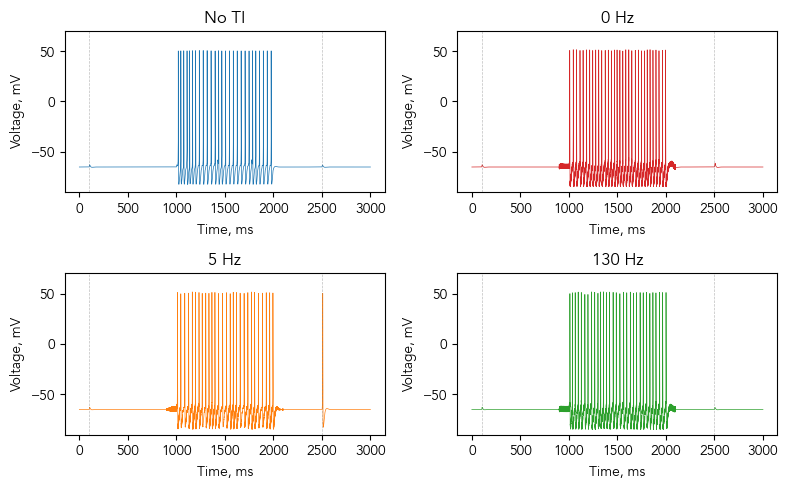

In [5]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (8, 2 * 2.5))
axs = axs.flatten()

for condition, ax in zip(conditions.keys(), axs):
    filename = conditions[condition]
    color = colors[condition]

    voltage = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/voltage.csv")

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = color
    )

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_ylim(-90, 70)

    ax.set_title(condition)

    ax.axvline(test_stimulus_1, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)
    ax.axvline(test_stimulus_2, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)

fig.tight_layout()
plt.show()

## Multiple runs

In [6]:
idxs = np.arange(0, 20)

conditions = {
    "No TI": "ltp/noTI_0.1"
}

colors = {
    "No TI": "tab:blue"
}

FileNotFoundError: [Errno 2] No such file or directory: 'output/temporal-interference/0/subthreshold_conductance_results.csv'

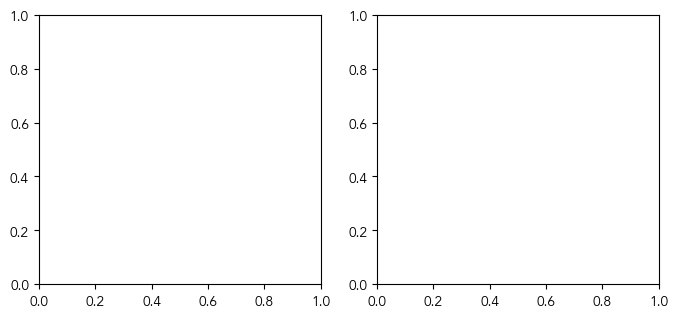

In [7]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 3.5))

final_conductance = []
for idx in idxs:
    results = pd.read_csv(f"output/temporal-interference/{idx}/subthreshold_conductance_results.csv")
    final_conductance.append(results.iloc[-1].Conductance)

    axs[0].plot(
        results.index,
        results.Conductance * 1000_000,
        linewidth = 0.75,
        color = "black"
    )

axs[0].set_xlabel("Iteration")
axs[0].set_ylabel(r"Conductance, pS")
axs[0].set_ylim(0, 0.00011 * 1000_000)
axs[0].set_yticks(range(0, 125, 25))
axs[0].set_title("Estimation")
axs[0].grid(True, alpha = 0.3)
axs[0].set_xticks(range(0, 10, 1))

axs[1].hist(np.array(final_conductance) * 1000_000, bins = 10, orientation = "horizontal", facecolor = (0, 0, 0, 0.075), edgecolor = "black", linewidth = 0.75)
axs[1].set_ylabel(r"Conductance, pS")
axs[1].set_xlabel("Count")
axs[1].set_title("Distribution")
axs[1].set_ylim(0, 110)
axs[1].set_yticks(range(0, 125, 25))
axs[1].grid(True, alpha = 0.3)
axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()

fig.suptitle("Subthreshold conductance")
fig.tight_layout()
plt.show()

0.000075
0.075 # nS
1 # nS in biological

# this is pS

# TODO: show a range of values (show that there is no spiking activity with lower conductance and that there is spiking with higher conductance, and that at some point it gives a spike both before and after LTP induction)

Subthreshold conductance was estimated in such a way that there would be no action potentials before or after LTP protocol; during LTP induction, the synapses generate dendritic spikes (but not necessarily somatic spikes).

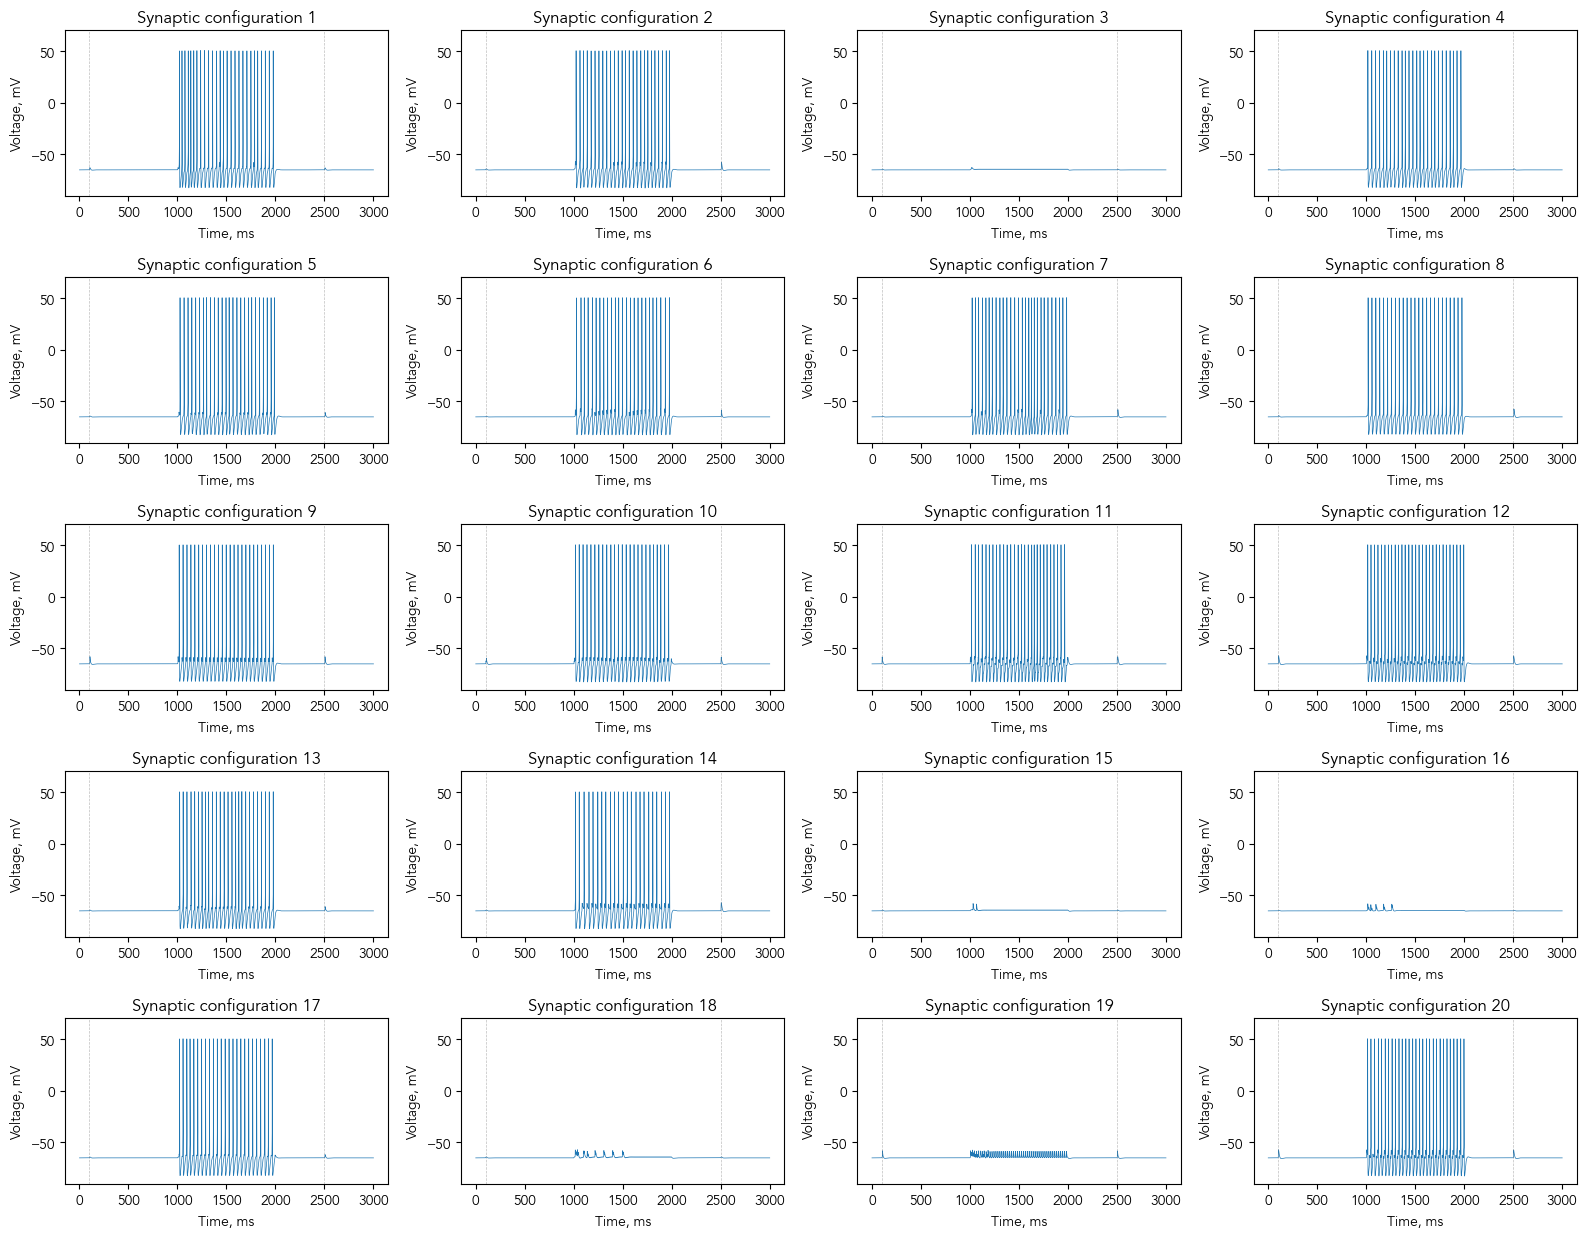

In [12]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (16, int(len(idxs) / 4) * 2.5))
axs = axs.flatten()

for idx, ax in zip(idxs, axs):
    for condition in conditions.keys():
        filename = conditions[condition]
        color = colors[condition]
        
        voltage = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/voltage.csv")

        ax.plot(
            voltage.Time,
            voltage.Voltage,
            linewidth = 0.5,
            color = color
        )

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_ylim(-90, 70)

    ax.set_title(f"Synaptic configuration {idx + 1}")
    
    ax.axvline(test_stimulus_1, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)
    ax.axvline(test_stimulus_2, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)

fig.tight_layout()
plt.show()

# TODO: 3 conditions (no spikes after/before, spike 50% after, spike 100% after)

In [13]:
def match_array_size(*arrays):
    min_len = min(arr.shape[0] for arr in arrays)
    return [arr[:min_len] for arr in arrays]

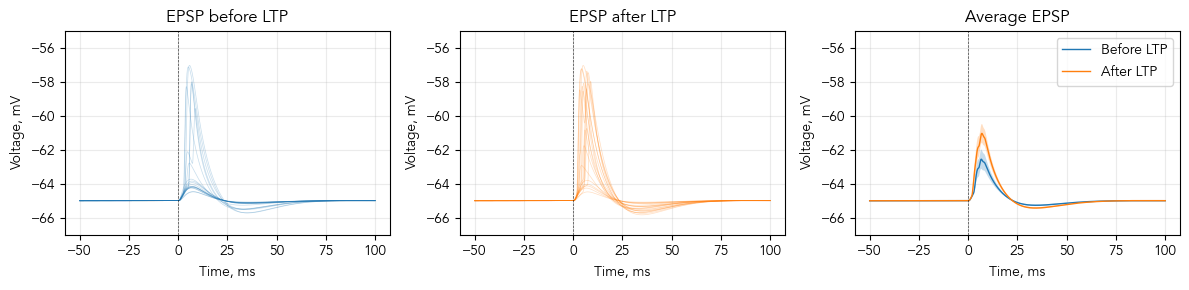

In [22]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3))
axs = axs.flatten()

condition = "No TI"
filename = conditions[condition]
    
epsp_before = []
epsp_after = []

time = []

for idx in idxs:
    voltage = pd.read_csv(f"output/temporal-interference-1/{idx}/{filename}/voltage.csv")
    
    time_epsp_before = np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
    epsp_before_idx = np.array(voltage.Voltage[time_epsp_before].tolist())
    epsp_before.append(epsp_before_idx)
    
    time_epsp_after = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
    epsp_after_idx = np.array(voltage.Voltage[time_epsp_after].tolist())
    epsp_after.append(epsp_after_idx)

    time = np.array((voltage.Time[time_epsp_before] - test_stimulus_1).tolist())
    time, epsp_before_idx, epsp_after_idx = match_array_size(time, epsp_before_idx, epsp_after_idx)
    
    axs[0].plot(
        time,
        epsp_before_idx,
        linewidth = 0.5,
        alpha = 0.25,
        color = "tab:blue"
    )
    
    axs[1].plot(
        time,
        epsp_after_idx,
        linewidth = 0.5,
        alpha = 0.25,
        color = "tab:orange"
    )

epsp_before = np.array(epsp_before).T
epsp_after = np.array(epsp_after).T

time, epsp_before, epsp_after = match_array_size(time, epsp_before, epsp_after)

mean = epsp_before.mean(axis = 1)
error = epsp_before.std(axis = 1)  / np.sqrt(epsp_before.shape[1])

axs[2].plot(
    time,
    mean,
    linewidth = 1,
    label = "Before LTP"
)
axs[2].fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

mean = epsp_after.mean(axis = 1)
error = epsp_after.std(axis = 1) / np.sqrt(epsp_after.shape[1])

axs[2].plot(
    time,
    mean,
    linewidth = 1,
    label = "After LTP"
)
axs[2].fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

for ax in axs:
    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_ylim(-67, -55)
    ax.axvline(0, linewidth = 0.5, linestyle = "--", color = "black", alpha = 0.75)
    ax.grid(True, alpha = 0.25)

axs[0].set_title("EPSP before LTP")
axs[1].set_title("EPSP after LTP")
axs[2].set_title("Average EPSP")

axs[2].legend()

fig.tight_layout()
plt.show()

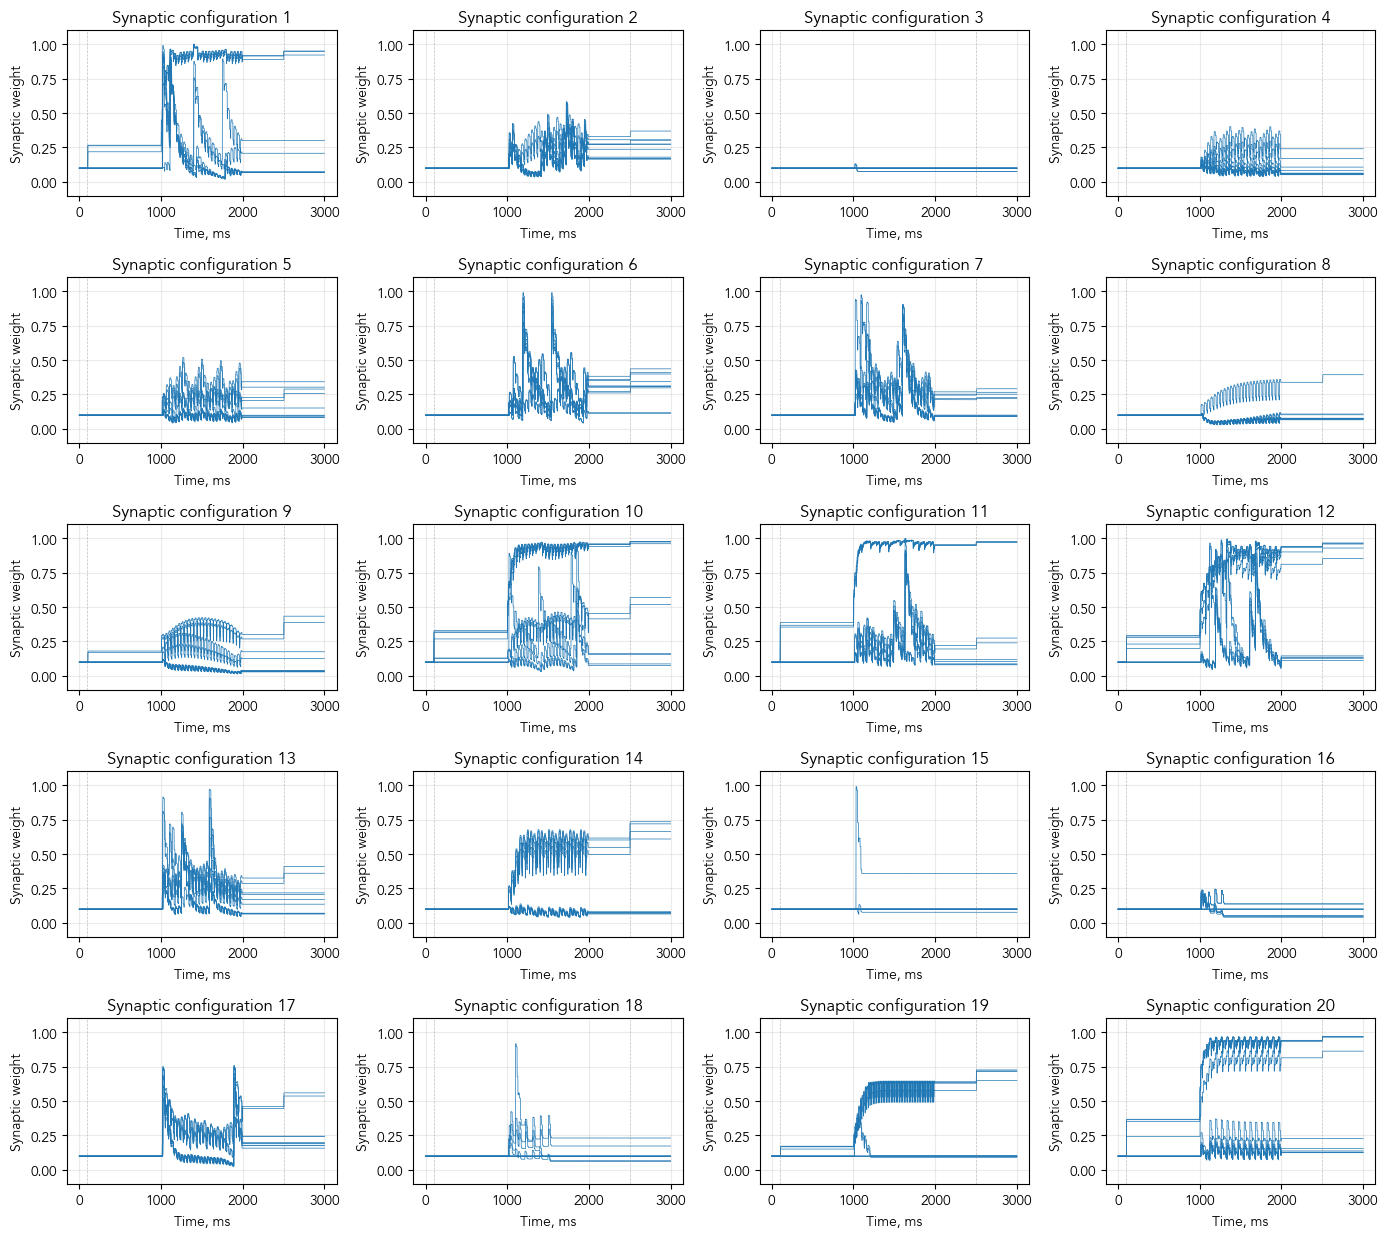

In [83]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (14, int(len(idxs) / 4) * 2.5))
axs = axs.flatten()

for idx, ax in zip(idxs, axs):
    for condition in conditions.keys():
        filename = conditions[condition]
        color = colors[condition]
        
        weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv", index_col = 0)
        synapses = [f"Synapse{i}" for i in range(10)]
        
        for synapse in synapses:
            ax.plot(
                weights.Time,
                weights[synapse],
                linewidth = 0.5,
                color = color
            )
    
    ax.set_title(f"Synaptic configuration {idx + 1}")
    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Synaptic weight")
    ax.set_ylim(-0.1, 1.1)

    ax.axvline(test_stimulus_1, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)
    ax.axvline(test_stimulus_2, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)
    
    ax.grid(True, alpha = 0.25)

fig.tight_layout()
plt.show()

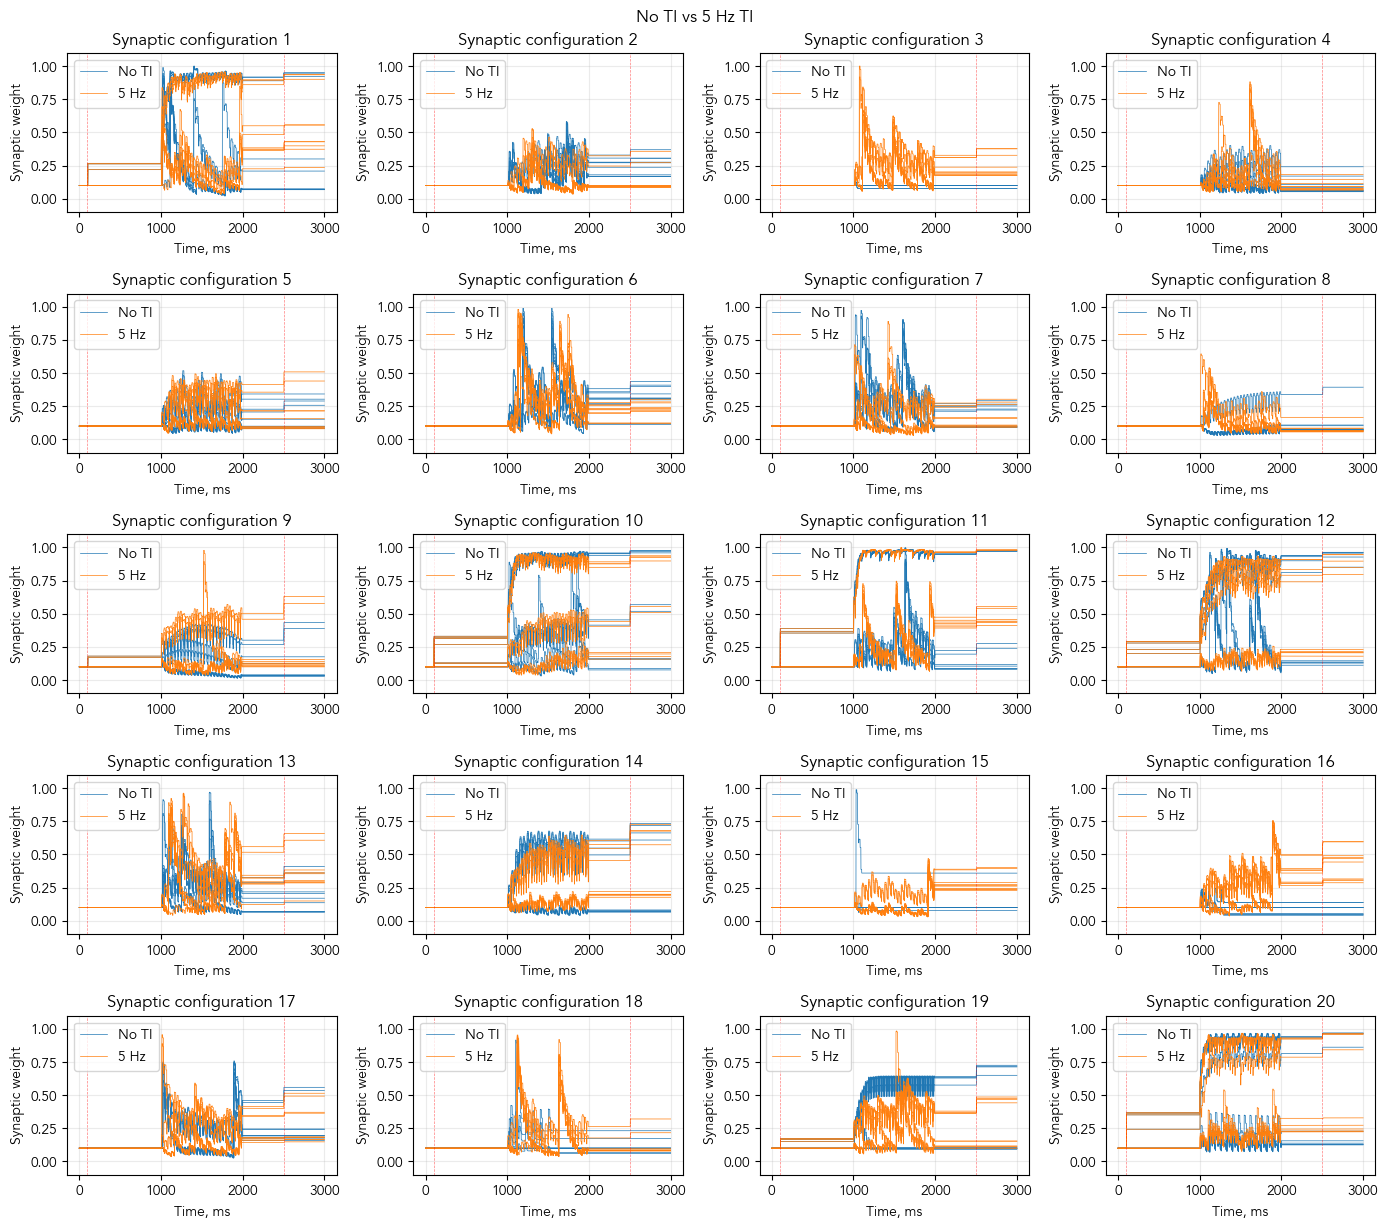

In [91]:
conditions = {
    "No TI": "ltp/noTI_0.1",
    # "0 Hz": "ltp/1000_0_0.9_0.1",
    "5 Hz": "ltp/1000_5_0.9_0.1",
    # "130 Hz": "ltp/1000_130_0.9_0.1"
}

colors = {
    "No TI": "tab:blue",
    "0 Hz": "tab:red",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green"
}

fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (14, int(len(idxs) / 4) * 2.5))
axs = axs.flatten()

for idx, ax in zip(idxs, axs):
    for condition in conditions.keys():
        filename = conditions[condition]
        color = colors[condition]

        weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv", index_col = 0)
        synapses = [f"Synapse{i}" for i in range(10)]

        for synapse in synapses:
            label = condition if synapse == "Synapse0" else ""
            
            ax.plot(
                weights.Time,
                weights[synapse],
                linewidth = 0.5,
                color = color,
                label = label
            )

    ax.set_title(f"Synaptic configuration {idx + 1}")
    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Synaptic weight")
    ax.set_ylim(-0.1, 1.1)

    ax.axvline(test_stimulus_1, linewidth = 0.5, color = "red", linestyle = "--", alpha = 0.5)
    ax.axvline(test_stimulus_2, linewidth = 0.5, color = "red", linestyle = "--", alpha = 0.5)

    ax.grid(True, alpha = 0.25)
    ax.legend(loc = "upper left")

fig.suptitle("No TI vs 5 Hz TI")
fig.tight_layout()
plt.show()

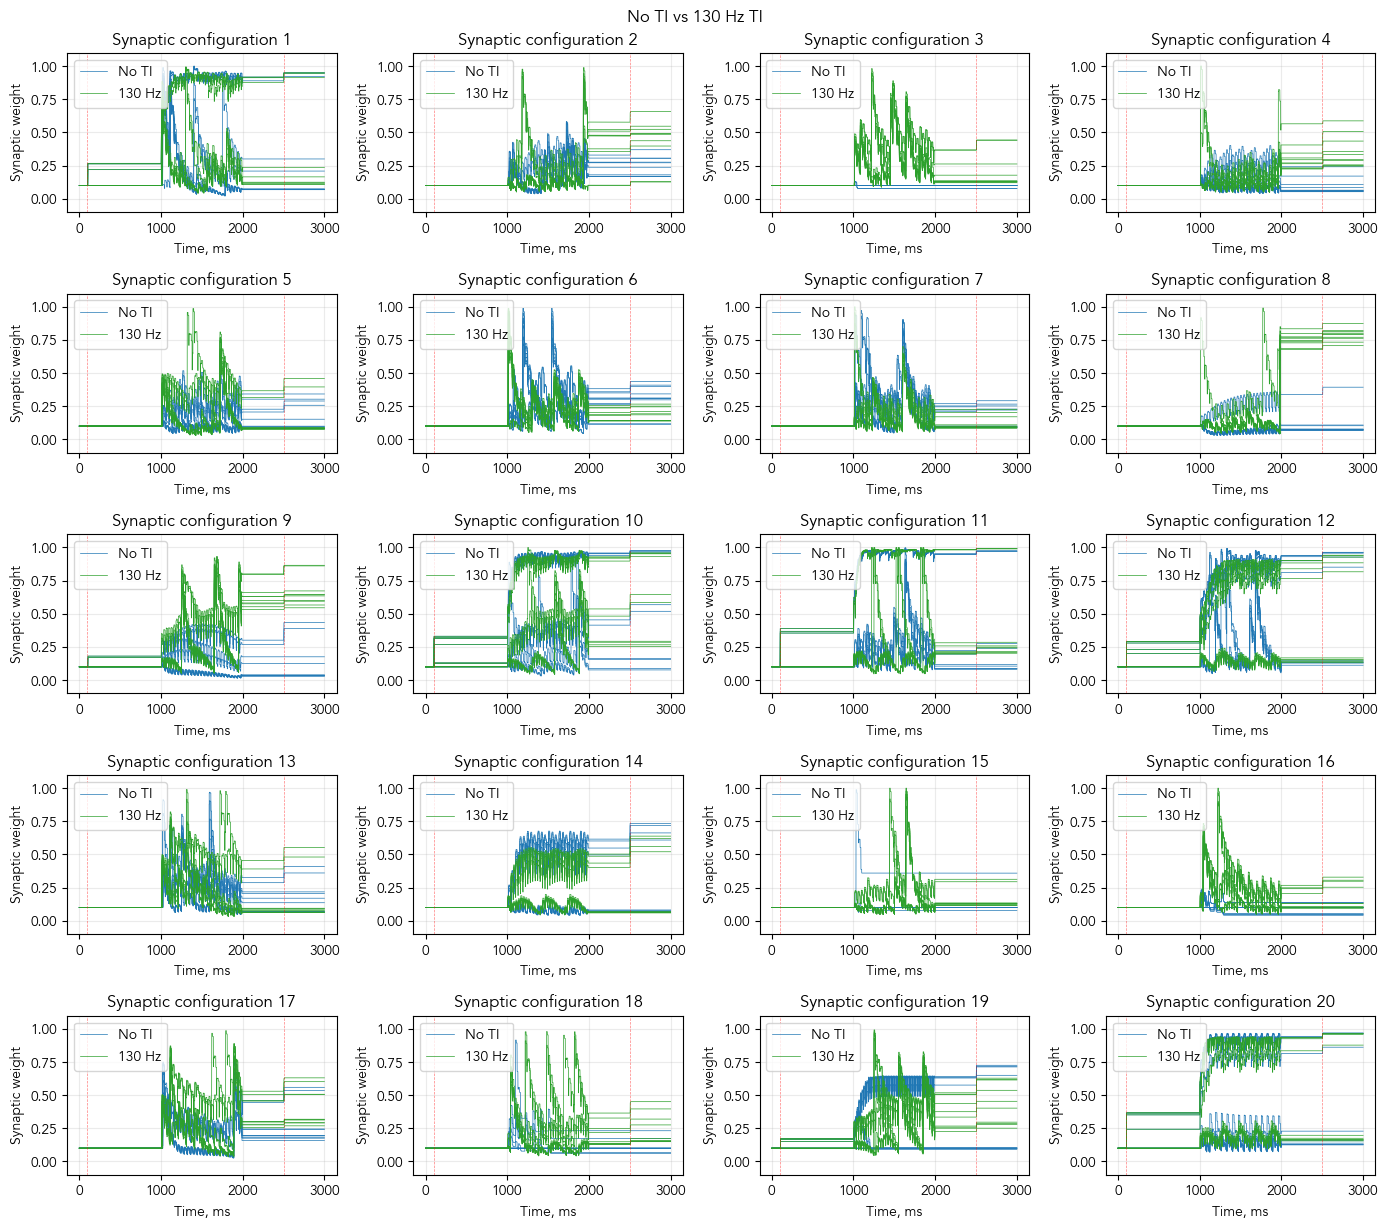

In [90]:
conditions = {
    "No TI": "ltp/noTI_0.1",
    # "0 Hz": "ltp/1000_0_0.9_0.1",
    # "5 Hz": "ltp/1000_5_0.9_0.1",
    "130 Hz": "ltp/1000_130_0.9_0.1"
}

colors = {
    "No TI": "tab:blue",
    "0 Hz": "tab:red",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green"
}

fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (14, int(len(idxs) / 4) * 2.5))
axs = axs.flatten()

for idx, ax in zip(idxs, axs):
    for condition in conditions.keys():
        filename = conditions[condition]
        color = colors[condition]

        weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv", index_col = 0)
        synapses = [f"Synapse{i}" for i in range(10)]

        for synapse in synapses:
            label = condition if synapse == "Synapse0" else ""

            ax.plot(
                weights.Time,
                weights[synapse],
                linewidth = 0.5,
                color = color,
                label = label
            )

    ax.set_title(f"Synaptic configuration {idx + 1}")
    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Synaptic weight")
    ax.set_ylim(-0.1, 1.1)

    ax.axvline(test_stimulus_1, linewidth = 0.5, color = "red", linestyle = "--", alpha = 0.5)
    ax.axvline(test_stimulus_2, linewidth = 0.5, color = "red", linestyle = "--", alpha = 0.5)

    ax.grid(True, alpha = 0.25)
    ax.legend(loc = "upper left")

fig.suptitle("No TI vs 130 Hz TI")
fig.tight_layout()
plt.show()